# 4. FilterCatalog Test & Set
## RDKit filter catalog

In [2]:
!pip install rdkit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 62.6 MB/s eta 0:00:00


In [3]:
from rdkit import Chem
from rdkit.Chem import FilterCatalog

# PAINS와 BRENK 필터를 모두 활성화
params = FilterCatalog.FilterCatalogParams()
params.AddCatalog(FilterCatalog.FilterCatalogParams.FilterCatalogs.PAINS)
params.AddCatalog(FilterCatalog.FilterCatalogParams.FilterCatalogs.BRENK)
catalog = FilterCatalog.FilterCatalog(params)

# 테스트: 니트로기(nitro group)를 가진 간단한 분자
test_smiles = "c1ccc(cc1)[N+](=O)[O-]"  # nitrobenzene
mol = Chem.MolFromSmiles(test_smiles)

matches = catalog.GetMatches(mol)
for match in matches:
    print("매치된 규칙:", match.GetDescription())

매치된 규칙: nitro_group
매치된 규칙: Oxygen-nitrogen_single_bond


In [4]:
print([m for m in dir(match) if not m.startswith('_')])

['ClearProp', 'GetDescription', 'GetFilterMatches', 'GetProp', 'GetPropList', 'HasFilterMatch', 'IsValid', 'Serialize', 'SetDescription', 'SetProp']


In [5]:
filter_matches = match.GetFilterMatches(mol)
print(filter_matches)
print(type(filter_matches))
first = filter_matches[0]
print([m for m in dir(first) if not m.startswith('_')])

<class 'rdkit.Chem.rdfiltercatalog.VectFilterMatch'>
['atomPairs', 'filterMatch']


In [6]:
first_match = filter_matches[0]
print("atomPairs:", first_match.atomPairs)
print("filterMatch:", first_match.filterMatch)
for smarts_idx, mol_atom_idx in first_match.atomPairs:
    atom = mol.GetAtomWithIdx(mol_atom_idx)
    print(f"분자 내 원자 인덱스 {mol_atom_idx}: {atom.GetSymbol()}")

atomPairs: <rdkit.rdBase.MatchTypeVect object at 0x797158e26ea0>
filterMatch: Oxygen-nitrogen_single_bond
분자 내 원자 인덱스 6: N
분자 내 원자 인덱스 8: O


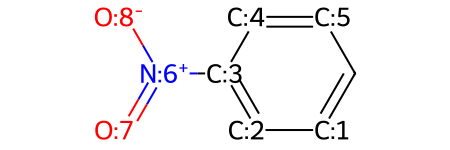

In [7]:
from rdkit.Chem.Draw import rdMolDraw2D

def draw_with_indices(mol):
    mol_copy = Chem.Mol(mol)
    for atom in mol_copy.GetAtoms():
        atom.SetAtomMapNum(atom.GetIdx())
    return mol_copy

mol_labeled = draw_with_indices(mol)
mol_labeled

In [8]:
!pwd
!ls

/content
sample_data


In [9]:
from google.colab import userdata
token = userdata.get('GITHUB_TOKEN')

!git clone https://{token}@github.com/Dec32th/laidd-2026.git
%cd /content/laidd-2026
!pwd
!ls

Cloning into 'laidd-2026'...
remote: Enumerating objects: 42, done.
remote: Counting objects: 100% (42/42), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 42 (delta 6), reused 26 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (42/42), 220.64 KiB | 12.98 MiB/s, done.
Resolving deltas: 100% (6/6), done.
/content/laidd-2026
/content/laidd-2026
data  docs  models  notebooks  outputs	README.md  references  src


In [10]:
%%writefile src/tools/toxicophore_detector.py
from rdkit import Chem
from rdkit.Chem import FilterCatalog

def _build_catalog():
    params = FilterCatalog.FilterCatalogParams()
    params.AddCatalog(FilterCatalog.FilterCatalogParams.FilterCatalogs.PAINS)
    params.AddCatalog(FilterCatalog.FilterCatalogParams.FilterCatalogs.BRENK)
    return FilterCatalog.FilterCatalog(params)

_catalog = _build_catalog()

def detect_toxicophores(smiles: str) -> list[dict]:
    """
    분자의 SMILES를 받아, FilterCatalog(PAINS+BRENK)에 매치되는
    문제 구조(toxicophore)들을 찾아서 규칙 이름과 해당 원자 인덱스를 반환.
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return []

    results = []
    for entry in _catalog.GetMatches(mol):
        for fm in entry.GetFilterMatches(mol):
            atom_indices = sorted(set(mol_idx for _, mol_idx in fm.atomPairs))
            results.append({
                "rule": fm.filterMatch,
                "description": entry.GetDescription(),
                "atom_indices": atom_indices,
            })
    return results

Writing src/tools/toxicophore_detector.py


In [11]:
import importlib
import src.tools.toxicophore_detector
importlib.reload(src.tools.toxicophore_detector)
from src.tools.toxicophore_detector import detect_toxicophores

result = detect_toxicophores("c1ccc(cc1)[N+](=O)[O-]")
for r in result:
    print(r)

{'rule': <rdkit.Chem.rdfiltercatalog.SmartsMatcher object at 0x797158486880>, 'description': 'nitro_group', 'atom_indices': [6, 7, 8]}
{'rule': <rdkit.Chem.rdfiltercatalog.SmartsMatcher object at 0x7971584868f0>, 'description': 'Oxygen-nitrogen_single_bond', 'atom_indices': [6, 8]}


In [13]:
%%writefile src/tools/toxicophore_detector.py
from rdkit import Chem
from rdkit.Chem import FilterCatalog

def _build_catalog():
    params = FilterCatalog.FilterCatalogParams()
    params.AddCatalog(FilterCatalog.FilterCatalogParams.FilterCatalogs.PAINS)
    params.AddCatalog(FilterCatalog.FilterCatalogParams.FilterCatalogs.BRENK)
    return FilterCatalog.FilterCatalog(params)

_catalog = _build_catalog()

def detect_toxicophores(smiles: str) -> list[dict]:
    """
    분자의 SMILES를 받아, FilterCatalog(PAINS+BRENK)에 매치되는
    문제 구조(toxicophore)들을 찾아서 규칙 이름과 해당 원자 인덱스를 반환.
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return []

    results = []
    for entry in _catalog.GetMatches(mol):
        for fm in entry.GetFilterMatches(mol):
            atom_indices = sorted(set(mol_idx for _, mol_idx in fm.atomPairs))
            results.append({
                "rule_name": entry.GetDescription(),
                "atom_indices": atom_indices,
            })
    return results

Overwriting src/tools/toxicophore_detector.py


In [14]:
import importlib
import src.tools.toxicophore_detector
importlib.reload(src.tools.toxicophore_detector)
from src.tools.toxicophore_detector import detect_toxicophores

result = detect_toxicophores("c1ccc(cc1)[N+](=O)[O-]")
for r in result:
    print(r)

import json
print(json.dumps(result))  # 에러 없이 JSON 문자열로 잘 변환되는지 확인

{'rule_name': 'nitro_group', 'atom_indices': [6, 7, 8]}
{'rule_name': 'Oxygen-nitrogen_single_bond', 'atom_indices': [6, 8]}
[{"rule_name": "nitro_group", "atom_indices": [6, 7, 8]}, {"rule_name": "Oxygen-nitrogen_single_bond", "atom_indices": [6, 8]}]


In [15]:
!pwd
!ls src/tools/

/content/laidd-2026
data_prep.py  __pycache__  toxicophore_detector.py


In [16]:
!git add src/tools/toxicophore_detector.py
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   src/tools/toxicophore_detector.py



In [17]:
!git config --global user.email "hkw_61@naver.com"
!git config --global user.name "Dec32th"
!git commit -m "Add toxicophore detector using RDKit FilterCatalog (PAINS+BRENK)"
!git push https://{token}@github.com/Dec32th/laidd-2026.git

[main eb4db59] Add toxicophore detector using RDKit FilterCatalog (PAINS+BRENK)
 1 file changed, 29 insertions(+)
 create mode 100644 src/tools/toxicophore_detector.py
Enumerating objects: 8, done.
Counting objects: 100% (8/8), done.
Delta compression using up to 2 threads
Compressing objects: 100% (5/5), done.
Writing objects: 100% (5/5), 983 bytes | 983.00 KiB/s, done.
Total 5 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
To https://github.com/Dec32th/laidd-2026.git
   9dfa196..eb4db59  main -> main


In [21]:
%%writefile src/tools/replacement_library.py

REPLACEMENT_LIBRARY = {
    "nitro_group": {
        "problem_smarts": "[N+](=O)[O-]",
        "candidates": [
            {"smiles": "N", "name": "primary amine",
             "rationale": "극성을 유지하면서 니트로기의 환원성 대사 중간체 생성 경로를 제거함"},
            {"smiles": "S(=O)(=O)N", "name": "sulfonamide",
             "rationale": "약물유사 골격에서 흔히 쓰이는 안정적 대체기로, 수소결합 donor/acceptor 특성을 일부 유지"},
            {"smiles": "C#N", "name": "nitrile",
             "rationale": "대사 안정성이 개선된 사례가 문헌에 다수 보고됨, 다만 극성은 다소 감소"},
        ],
    },
    "aldehyde": {
        "problem_smarts": "[CX3H1](=O)",
        "candidates": [
            {"smiles": "C(=O)N", "name": "amide",
             "rationale": "알데히드의 친전자성(단백질 부가물 형성 우려)을 제거하면서 유사한 형태 유지"},
            {"smiles": "C(O)", "name": "alcohol",
             "rationale": "가장 단순한 환원형 대체, 반응성 크게 감소"},
        ],
    },
    "michael_acceptor": {
        "problem_smarts": "C=CC(=O)",
        "candidates": [
            {"smiles": "CCC(=O)", "name": "saturated ketone",
             "rationale": "이중결합을 제거해 단백질 친전자성 부가반응(covalent binding) 위험 제거"},
        ],
    },
    "thiourea": {
        "problem_smarts": "NC(=S)N",
        "candidates": [
            {"smiles": "NC(=O)N", "name": "urea",
             "rationale": "황 원자를 산소로 대체, 유사한 형태를 유지하면서 반응성/대사 우려 감소"},
        ],
    },
    "acyl_halide": {
        "problem_smarts": "C(=O)[F,Cl,Br,I]",
        "candidates": [
            {"smiles": "C(=O)N", "name": "amide",
             "rationale": "고반응성 아실할라이드를 안정적인 아마이드로 대체"},
        ],
    },
}

def get_replacement_candidates(rule_name: str) -> dict | None:
    """rule_name에 해당하는 치환 정보(SMARTS + 후보 리스트)를 반환. 없으면 None."""
    return REPLACEMENT_LIBRARY.get(rule_name)

Overwriting src/tools/replacement_library.py


In [20]:
import importlib
import src.tools.replacement_library
importlib.reload(src.tools.replacement_library)
from src.tools.replacement_library import get_replacement_candidates

result = get_replacement_candidates("nitro_group")
print(result)

{'problem_smarts': '[N+](=O)[O-]', 'candidates': [{'smiles': 'N', 'name': 'primary amine', 'rationale': '극성을 유지하면서 니트로기의 환원성 대사 중간체 생성 경로를 제거함'}, {'smiles': 'S(=O)(=O)N', 'name': 'sulfonamide', 'rationale': '약물유사 골격에서 흔히 쓰이는 안정적 대체기로, 수소결합 донor/acceptor 특성을 일부 유지'}, {'smiles': 'C#N', 'name': 'nitrile', 'rationale': '대사 안정성이 개선된 사례가 문헌에 다수 보고됨, 다만 극성은 다소 감소'}]}


In [22]:
!pwd
!ls src/tools/

/content/laidd-2026
data_prep.py  __pycache__  replacement_library.py  toxicophore_detector.py


In [23]:
!git add src/tools/replacement_library.py
!git status

On branch main
Your branch is ahead of 'origin/main' by 1 commit.
  (use "git push" to publish your local commits)

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   src/tools/replacement_library.py



In [24]:
!git config --global user.email "hkw_61@naver.com"
!git config --global user.name "Dec32th"
!git commit -m "Add bioisostere replacement candidate library (5 toxicophore rules)"
!git push https://{token}@github.com/Dec32th/laidd-2026.git

[main 42f7214] Add bioisostere replacement candidate library (5 toxicophore rules)
 1 file changed, 48 insertions(+)
 create mode 100644 src/tools/replacement_library.py
Enumerating objects: 8, done.
Counting objects: 100% (8/8), done.
Delta compression using up to 2 threads
Compressing objects: 100% (5/5), done.
Writing objects: 100% (5/5), 1.38 KiB | 1.38 MiB/s, done.
Total 5 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
To https://github.com/Dec32th/laidd-2026.git
   eb4db59..42f7214  main -> main
